**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


## Support vector machines

### Data Preparation

In [ ]:
df_original = pd.read_csv("cmi_internet_copie.csv")
df = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,4,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,1,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,1,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,1,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0


In [71]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (8460, 83)
Shape y: (8460,)


### Data Partitioning

In [95]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

**Pipeline :  split - standardscaler - smote(K-NN) - SelectFromModel - model**

In [86]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

### Linear SVM

A crucial parameter is **C** :

Small C: the algorithm prioritizes a **wider margim**, even if the means accepting some classification errors. this promotes generalization and reduces the risk of overfitting

Large C: the algorithm aims(wants) **to correctly classify every training point**, which results in a narrower(più stretto) margin. this can lead to a model to a model that performs very well on training data but poorly on new data

In [7]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours
from scikitplot.metrics import plot_roc
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

In [13]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [14]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 28)

In [12]:
from sklearn.svm import LinearSVC

In [15]:
clf = LinearSVC(C=1.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5267927501970056
F1-score [0.7039627  0.33168317 0.34771242 0.052     ]
              precision    recall  f1-score   support

         0.0       0.84      0.60      0.70      1749
         1.0       0.41      0.28      0.33       482
         2.0       0.27      0.47      0.35       280
         3.0       0.03      0.48      0.05        27

    accuracy                           0.53      2538
   macro avg       0.39      0.46      0.36      2538
weighted avg       0.69      0.53      0.59      2538



Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.61      0.71      1749
         1.0       0.41      0.30      0.35       482
         2.0       0.28      0.48      0.35       280
         3.0       0.03      0.44      0.05        27

    accuracy                           0.54      2538
   macro avg       0.39      0.46      0.36      2538
weighted avg       0.69      0.54      0.59      2538



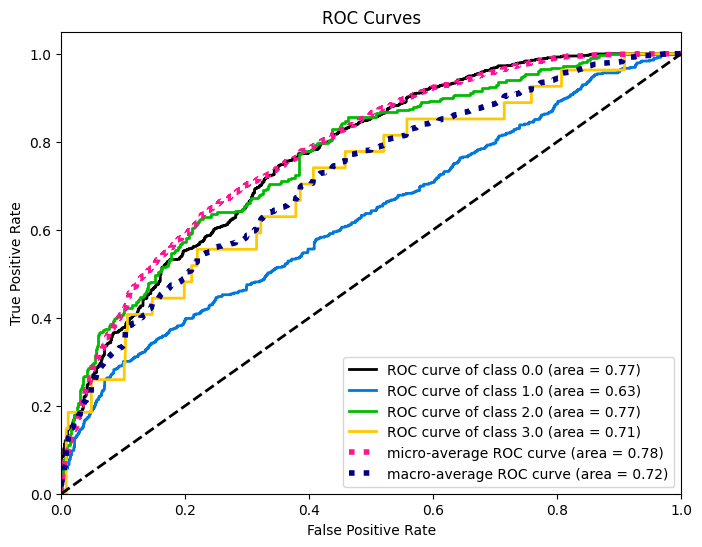

In [17]:
from sklearn.calibration import CalibratedClassifierCV
import scikitplot as skplt


# 2. Model Definition & Calibration
# Wrapping LinearSVC allows it to calculate probabilities
clf = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000))
clf.fit(X_train_sel, y_train_resampled)

# 3. Predictions
y_pred = clf.predict(X_test_sel)
y_score = clf.predict_proba(X_test_sel)

# 4. Text Evaluation (Contains Accuracy, F1, Precision, and Recall)
print("Classification Report:\n", classification_report(y_test, y_pred))

# 5. Visual Evaluation
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()

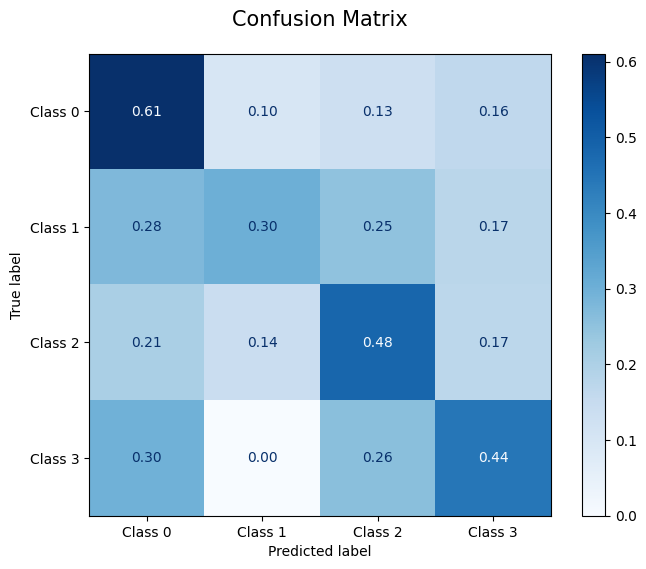

In [18]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [19]:
clf = LinearSVC(C=100.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5267927501970056
F1-score [0.7039627  0.33168317 0.34725849 0.05210421]
              precision    recall  f1-score   support

         0.0       0.84      0.60      0.70      1749
         1.0       0.41      0.28      0.33       482
         2.0       0.27      0.47      0.35       280
         3.0       0.03      0.48      0.05        27

    accuracy                           0.53      2538
   macro avg       0.39      0.46      0.36      2538
weighted avg       0.69      0.53      0.59      2538



In [20]:
clf = LinearSVC(C=0.001, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5185185185185185
F1-score [0.69728461 0.33753149 0.34126984 0.04788214]
              precision    recall  f1-score   support

         0.0       0.84      0.59      0.70      1749
         1.0       0.43      0.28      0.34       482
         2.0       0.27      0.46      0.34       280
         3.0       0.03      0.48      0.05        27

    accuracy                           0.52      2538
   macro avg       0.39      0.45      0.36      2538
weighted avg       0.69      0.52      0.58      2538



#### GridSearch

In [8]:
# Balance the Training Set (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [9]:
# Dimensionality Reduction (XGBoost)
selector = SelectFromModel(xgb.XGBClassifier(n_estimators=100, random_state=42))
selector.fit(X_train_res, y_train_res)

X_train_final = selector.transform(X_train_res)
X_test_final = selector.transform(X_test)

In [14]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],           # LinearSVC usually performs best with l2
    'loss': ['squared_hinge'],   # Standard for LinearSVC
    'max_iter': [2000],
    'dual': [False]              # Set dual=False when n_samples > n_features
}

In [15]:
# Grid Search 
# 'f1_weighted' is the key here. It won't crash on multiclass 
# and remains accurate for binary.
grid_search = GridSearchCV(
    LinearSVC(random_state=42), 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train_res)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'dual': [False], 'loss': ['squared_hinge'], 'max_iter': [2000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;

In [16]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'C': 1, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l2'}


In [18]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test_final)
# CHANGE: LinearSVC uses decision_function instead of predict_proba
y_prob = best_model.decision_function(X_test_final) 

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.5470

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.60      0.70      1749
         1.0       0.41      0.28      0.33       482
         2.0       0.27      0.47      0.35       280
         3.0       0.03      0.48      0.05        27

    accuracy                           0.53      2538
   macro avg       0.39      0.46      0.36      2538
weighted avg       0.69      0.53      0.59      2538



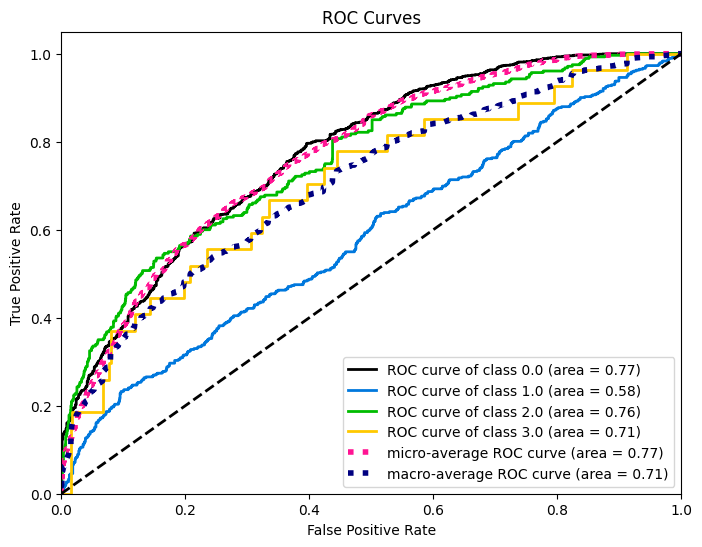

In [19]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_final)
y_score = best_model.decision_function(X_test_final)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


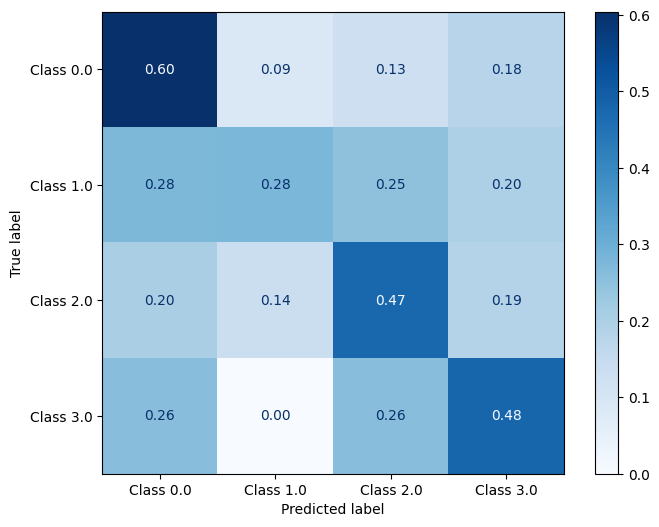

In [20]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

#### Randomized search

In [21]:
from scipy.stats import loguniform, uniform

In [25]:
# Define the Parameter Distributions
param_dist = {
    # loguniform is perfect for C to test different magnitudes
    'C': loguniform(1e-3, 1e2), 
    # LinearSVC only supports 'l1' or 'l2'
    'penalty': ['l1', 'l2'],
    # loss='squared_hinge' is standard; 'hinge' only works with penalty='l2'
    'loss': ['squared_hinge'],
    # dual=False is highly recommended when n_samples > n_features
    'dual': [False],
    'max_iter': [2000,5000]
}

In [26]:
# Configure the Randomized Search
random_search = RandomizedSearchCV(
    LinearSVC(random_state=42), 
    param_distributions=param_dist, 
    n_iter=20,               # The number of random combinations to try (adjust based on your time)
    cv=5, 
    scoring='f1_weighted',   # Universal metric for 2 or 4 classes
    n_jobs=-1, 
    random_state=42          # Ensures reproducibility 
)

# Fit the model
random_search.fit(X_train_final, y_train_res)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001E1989B73B0>, 'dual': [False], 'loss': ['squared_hinge'], 'max_iter': [2000, 5000], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged::

In [27]:
# Print the best parameters found
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")

Best Parameters: {'C': 0.14445251022763064, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l1'}
Best internal CV Score: 0.5474


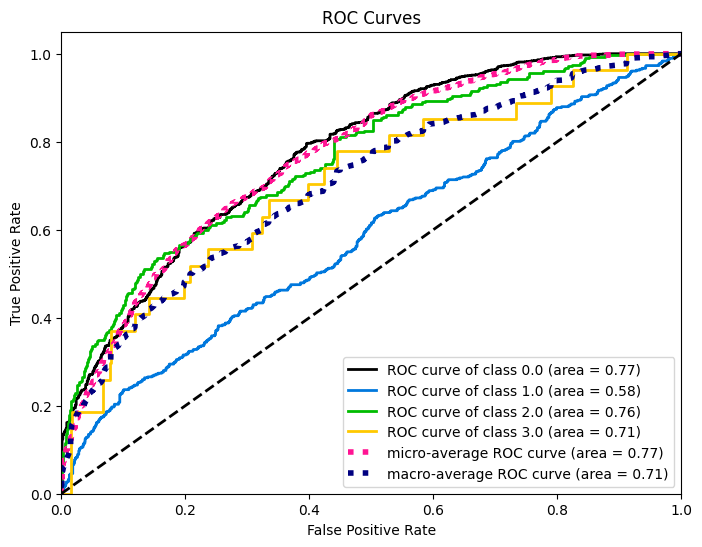

In [28]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_final)
y_score = best_model.decision_function(X_test_final)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


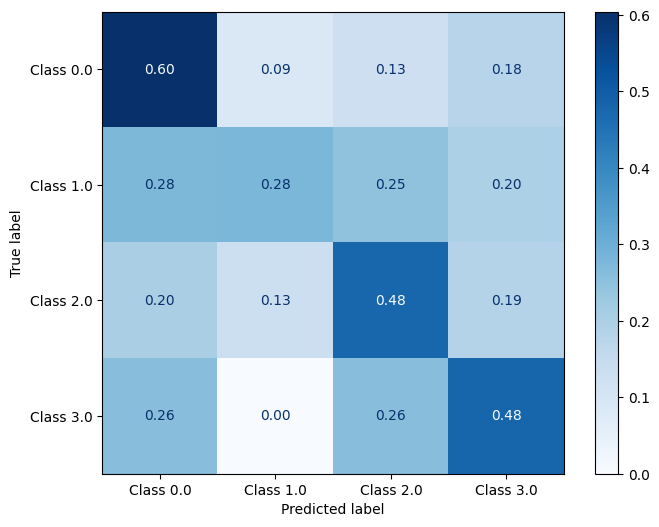

In [29]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

#### New Target variable

In [34]:
from collections import Counter
from collections import defaultdict

**Basic_Demos-Enroll_Season**

In [30]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,...,0,55.00,72.75,0,3,6.5,20.625,2.010,448.0,2.0
1,2,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,...,0,46.00,64.00,2,0,11.0,20.625,2.010,271.0,0.0
2,2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,...,0,38.00,54.00,2,2,10.0,12.450,2.010,453.0,0.0
3,3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,...,2,31.00,45.00,3,0,7.0,20.625,2.009,577.0,1.0
4,1,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,...,3,44.45,61.00,1,1,9.0,21.305,1.040,457.0,0.0


In [31]:
df_SVM = df.copy()

In [32]:
df.drop(columns=['Basic_Demos-Enroll_Season'], inplace=True)

In [33]:
X = df.values
y = np.array(df_SVM['Basic_Demos-Enroll_Season'])

In [35]:
ctr = Counter(y)
ctr

Counter({1: 2442, 3: 2131, 2: 2102, 0: 1785})

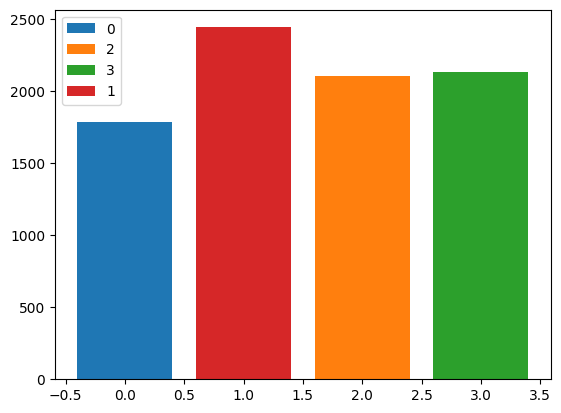

In [36]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [37]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0, 2.0, 3.0]
    colors  = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e']  # Verde, Rosso, Blu, Arancione

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [39]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 6844 samples
Distribution of classes after SMOTE : {0: 1711, 1: 1711, 2: 1711, 3: 1711}


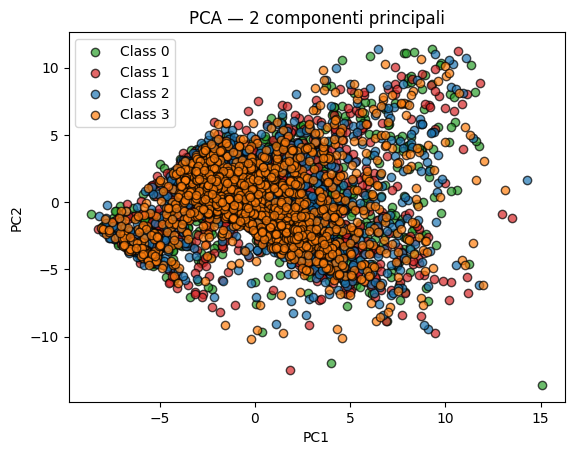

In [41]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train_resampled)
plot_pca(X_pca, y_train_resampled)

In [42]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(6844, 11)

In [44]:
clf = LinearSVC(C=1.0, random_state=42)

clf.fit(X_train_sel, y_train_resampled)
y_pred = clf.predict(X_test_sel)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6147
F1-score (par classe) : [0.61505982 0.48518519 0.58713693 0.71756673]

Classification Report complet :
              precision    recall  f1-score   support

           0       0.49      0.84      0.62       521
           1       0.75      0.36      0.49       731
           2       0.76      0.48      0.59       591
           3       0.63      0.83      0.72       695

    accuracy                           0.61      2538
   macro avg       0.66      0.63      0.60      2538
weighted avg       0.67      0.61      0.60      2538



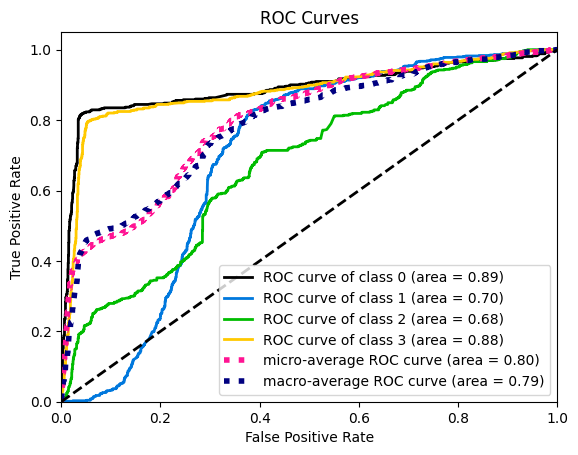

In [46]:
y_score = clf.decision_function(X_test_sel)
plot_roc(y_test, y_score)
plt.show()

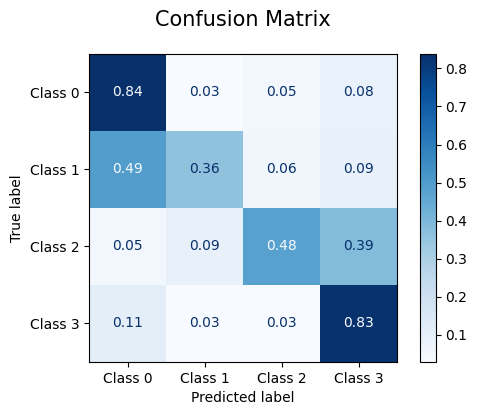

In [47]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

**Basic_Demos-Sex**

In [48]:
df["Basic_Demos-Enroll_Season"] = df_SVM["Basic_Demos-Enroll_Season"]
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii,Basic_Demos-Enroll_Season
0,5.0,0,3,51.0,0,16.877316,46.000,50.8,26.0,70.25,...,55.00,72.75,0,3,6.5,20.625,2.010,448.0,2.0,0
1,9.0,0,2,56.4,0,14.035590,48.000,46.0,22.0,75.00,...,46.00,64.00,2,0,11.0,20.625,2.010,271.0,0.0,2
2,10.0,1,0,71.0,0,16.648696,56.500,75.6,26.5,65.00,...,38.00,54.00,2,2,10.0,12.450,2.010,453.0,0.0,2
3,9.0,0,0,71.0,2,18.292347,56.000,81.6,26.0,60.00,...,31.00,45.00,3,0,7.0,20.625,2.009,577.0,1.0,3
4,18.0,1,2,65.0,2,17.937682,60.485,77.0,26.0,68.00,...,44.45,61.00,1,1,9.0,21.305,1.040,457.0,0.0,1


In [49]:
df_SVM = df.copy()

In [50]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [51]:
X = df.values
y = np.array(df_SVM['Basic_Demos-Sex'])

In [52]:
ctr = Counter(y)
ctr

Counter({0: 5056, 1: 3404})

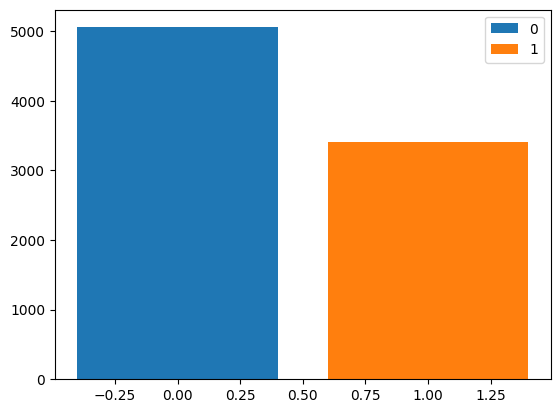

In [53]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [62]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0]
    colors  = ['#2ca02c', '#d62728']  # Verde, Rosso

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Class {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [56]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 7080 samples
Distribution of classes after SMOTE : {0: 3540, 1: 3540}


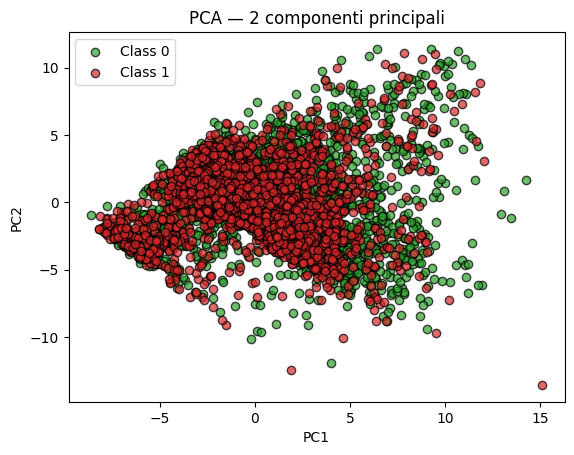

In [58]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train_resampled)
plot_pca(X_pca, y_train_resampled)

In [59]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(7080, 26)

In [60]:
clf = LinearSVC(C=1.0, random_state=42)

clf.fit(X_train_sel, y_train_resampled)
y_pred = clf.predict(X_test_sel)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-score (par classe) : {f1_score(y_test, y_pred, average=None)}")
print("\nClassification Report complet :")  
print(classification_report(y_test, y_pred))

Accuracy : 0.6217
F1-score (par classe) : [0.65738758 0.57783641]

Classification Report complet :
              precision    recall  f1-score   support

           0       0.72      0.61      0.66      1516
           1       0.52      0.64      0.58      1022

    accuracy                           0.62      2538
   macro avg       0.62      0.63      0.62      2538
weighted avg       0.64      0.62      0.63      2538



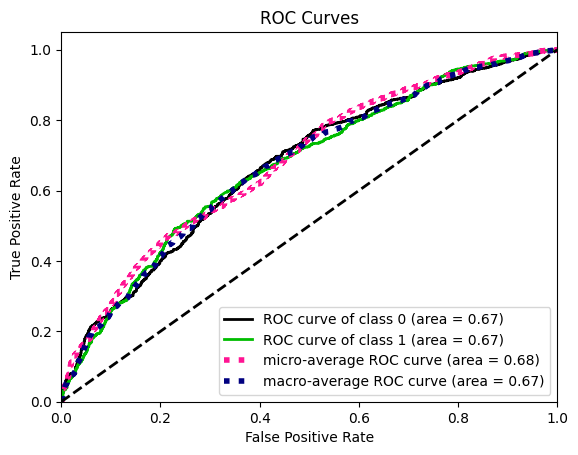

In [65]:
# 1. Get the 1D scores
y_score = clf.decision_function(X_test_sel)

# 2. Transform 1D scores into 2D "probabilities"
# We create a column for the negative class (0) and positive class (1)
y_score_2d = np.column_stack([1 - y_score, y_score])

# 3. Plot using the 2D array
plot_roc(y_test, y_score_2d)
plt.show()

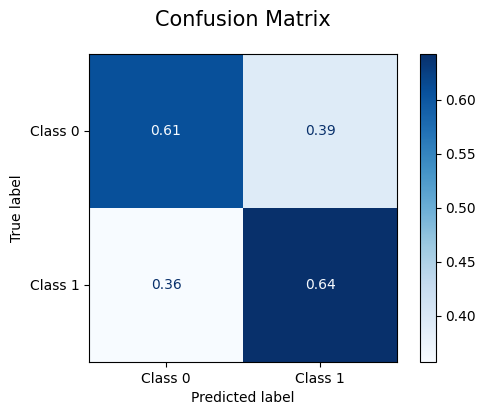

In [64]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(6, 4))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

### Nonlinear SVM

In [67]:
from sklearn.svm import SVC

In [74]:
# SMOTE 
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE : {X_train.shape[0]} samples")
print(f"After SMOTE : {X_train_resampled.shape[0]} samples")
print(f"Distribution of classes after SMOTE : {dict(zip(*np.unique(y_train_resampled, return_counts=True)))}")

Before SMOTE : 5922 samples
After SMOTE : 16336 samples
Distribution of classes after SMOTE : {0.0: 4084, 1.0: 4084, 2.0: 4084, 3.0: 4084}


In [75]:
# SelectFromModel with XGBoost

sel = SelectFromModel(xgb.XGBClassifier(random_state=42))
X_train_sel = sel.fit_transform(X_train_resampled, y_train_resampled)
X_test_sel = sel.transform(X_test)
X_train_sel.shape

(16336, 28)

In [76]:
clf = SVC(C=1.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.624113475177305
F1-score [0.7491515  0.45294118 0.40816327 0.1011236 ]
              precision    recall  f1-score   support

         0.0       0.81      0.69      0.75      1749
         1.0       0.43      0.48      0.45       482
         2.0       0.36      0.46      0.41       280
         3.0       0.06      0.33      0.10        27

    accuracy                           0.62      2538
   macro avg       0.42      0.49      0.43      2538
weighted avg       0.68      0.62      0.65      2538



Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.68      0.75      1749
         1.0       0.44      0.51      0.47       482
         2.0       0.36      0.51      0.42       280
         3.0       0.06      0.33      0.10        27

    accuracy                           0.63      2538
   macro avg       0.42      0.51      0.44      2538
weighted avg       0.70      0.63      0.65      2538



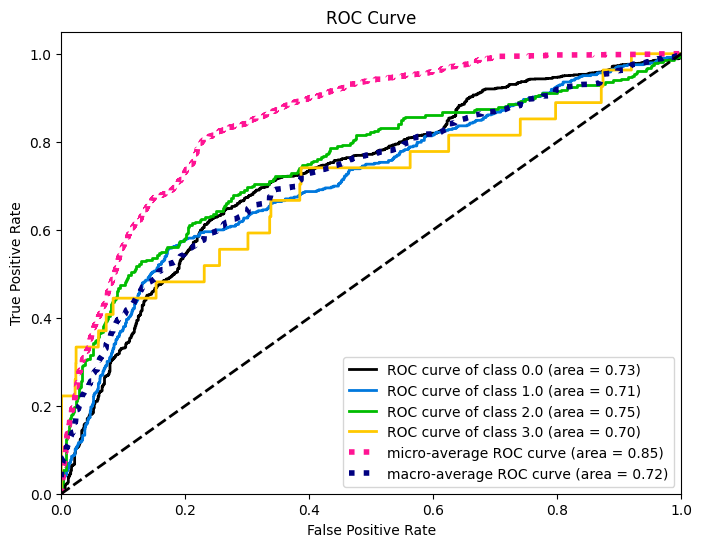

In [80]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import scikitplot as skplt

# SVC does not provide calibrated probabilities by default
base_clf = SVC(C=1.0, random_state=42, max_iter=5000)

clf = CalibratedClassifierCV(base_clf, method="sigmoid", cv=5)
clf.fit(X_train_sel, y_train_resampled)

# 2. Predictions
y_pred = clf.predict(X_test_sel)
y_score = clf.predict_proba(X_test_sel)

# 3. Text Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# 4. Visual Evaluation
skplt.metrics.plot_roc(
    y_test,
    y_score,
    figsize=(8, 6),
    title="ROC Curve"
)

plt.show()

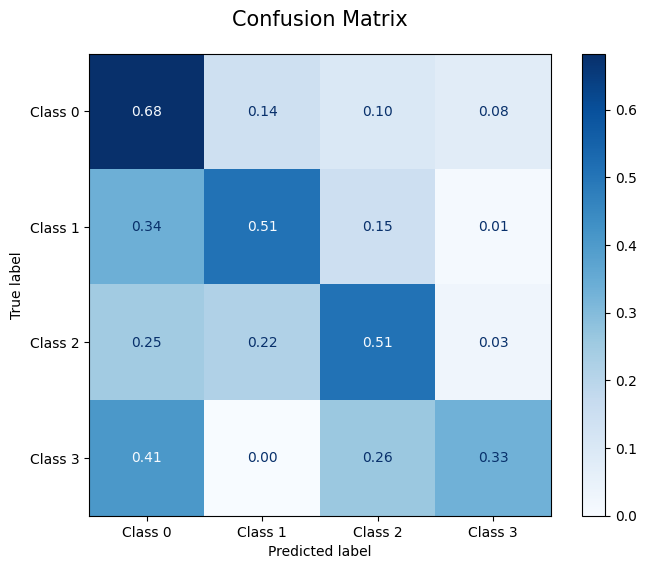

In [81]:
# 1. Crea la figura
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Usa 'normalize=true' per vedere le percentuali per riga
# Usiamo 'Blues' o 'Viridis' per una migliore leggibilità
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=["Class 0", "Class 1", "Class 2", "Class 3"], # Opzionale: nomi reali
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f' # Mostra solo 2 decimali
)

# 3. Personalizzazione estetica
ax.set_title("Confusion Matrix", fontsize=15, pad=20)
plt.grid(False) # Rimuove linee fastidiose se presenti
plt.show()

In [83]:
clf = SVC(C=100.0, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6579984239558707
F1-score [0.78718021 0.36170213 0.3671875  0.17910448]
              precision    recall  f1-score   support

         0.0       0.77      0.80      0.79      1749
         1.0       0.37      0.35      0.36       482
         2.0       0.41      0.34      0.37       280
         3.0       0.15      0.22      0.18        27

    accuracy                           0.66      2538
   macro avg       0.43      0.43      0.42      2538
weighted avg       0.65      0.66      0.65      2538



In [84]:
clf = SVC(C=0.001, random_state=42)
clf.fit(X_train_sel, y_train_resampled)

y_pred = clf.predict(X_test_sel)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.4661150512214342
F1-score [0.59865471 0.40427427 0.37940379 0.05565863]
              precision    recall  f1-score   support

         0.0       0.86      0.46      0.60      1749
         1.0       0.35      0.47      0.40       482
         2.0       0.31      0.50      0.38       280
         3.0       0.03      0.56      0.06        27

    accuracy                           0.47      2538
   macro avg       0.39      0.50      0.36      2538
weighted avg       0.70      0.47      0.53      2538



#### GridSearch

In [97]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('selector', SelectFromModel(xgb.XGBClassifier(n_estimators=100, random_state=42))),
    ('svm', SVC(random_state=42))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': [1e-3, 1e-2, 1e-1],
    'svm__kernel': ['rbf']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.01, 0.1, ...], 'svm__gamma': [0.001, 0.01, ...], 'svm__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [98]:
# Extract the Winning Parameters
print(f"Best Parameters found: {grid_search.best_params_}")

Best Parameters found: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}


In [100]:
# Grab the "Winning" model
best_model = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred = best_model.predict(X_test)
# CHANGE: LinearSVC uses decision_function instead of predict_proba
y_prob = best_model.decision_function(X_test) 

# 3. The Evaluation Report
print("Final evaluation on test set")
print(f"Best internal CV Score: {grid_search.best_score_:.4f}")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score 
print(classification_report(y_test, y_pred))

Final evaluation on test set
Best internal CV Score: 0.6643

Detailed Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.75      0.77      1749
         1.0       0.42      0.42      0.42       482
         2.0       0.39      0.43      0.41       280
         3.0       0.10      0.33      0.15        27

    accuracy                           0.65      2538
   macro avg       0.43      0.49      0.44      2538
weighted avg       0.67      0.65      0.66      2538



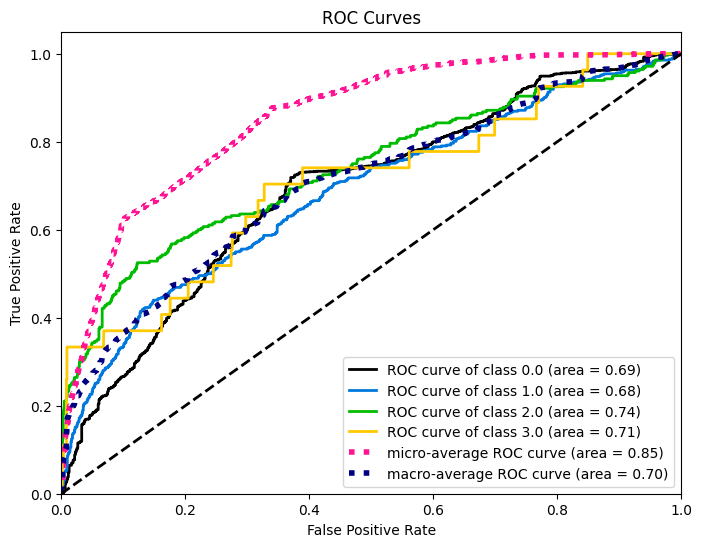

In [101]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_score = best_model.decision_function(X_test)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


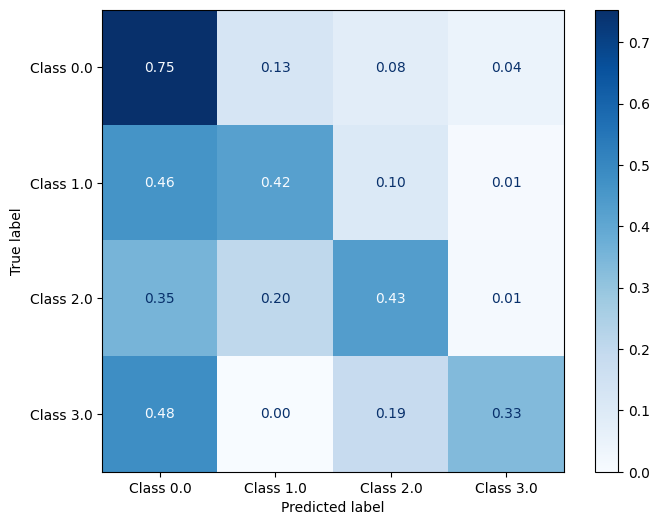

In [102]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)

#### Randomized search

In [ ]:
from scipy.stats import loguniform, uniform

In [ ]:
# Define the Parameter Distributions
param_dist = {
    # loguniform is perfect for C to test different magnitudes
    'C': loguniform(1e-3, 1e2), 
    # LinearSVC only supports 'l1' or 'l2'
    'penalty': ['l1', 'l2'],
    # loss='squared_hinge' is standard; 'hinge' only works with penalty='l2'
    'loss': ['squared_hinge'],
    # dual=False is highly recommended when n_samples > n_features
    'dual': [False],
    'max_iter': [2000,5000]
}

In [ ]:
# Configure the Randomized Search
random_search = RandomizedSearchCV(
    LinearSVC(random_state=42), 
    param_distributions=param_dist, 
    n_iter=20,               # The number of random combinations to try (adjust based on your time)
    cv=5, 
    scoring='f1_weighted',   # Universal metric for 2 or 4 classes
    n_jobs=-1, 
    random_state=42          # Ensures reproducibility 
)

# Fit the model
random_search.fit(X_train_final, y_train_res)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001E1989B73B0>, 'dual': [False], 'loss': ['squared_hinge'], 'max_iter': [2000, 5000], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged::

In [ ]:
# Print the best parameters found
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best internal CV Score: {random_search.best_score_:.4f}")

Best Parameters: {'C': 0.14445251022763064, 'dual': False, 'loss': 'squared_hinge', 'max_iter': 2000, 'penalty': 'l1'}
Best internal CV Score: 0.5474


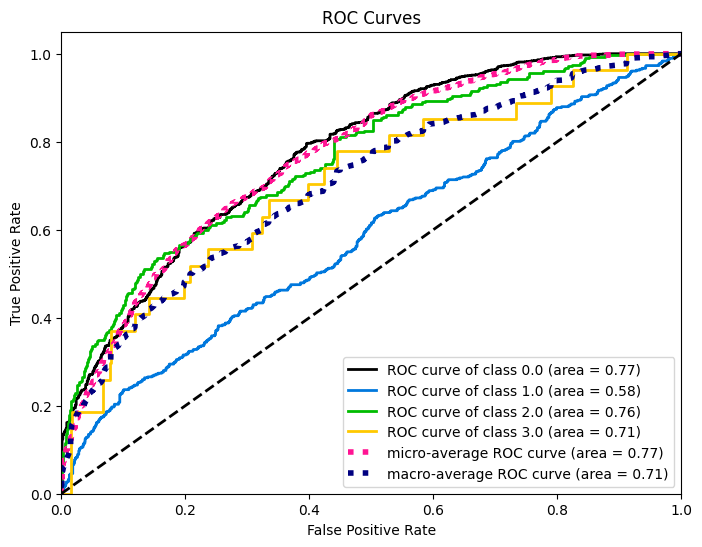

In [ ]:
import scikitplot as skplt 

# 1. Get predictions from the BEST model found by GridSearch
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_final)
y_score = best_model.decision_function(X_test_final)

# ROC curve 
# Works for both 2 and 4 classes
skplt.metrics.plot_roc(y_test, y_score, figsize=(8, 6), title="ROC Curves")
plt.show()


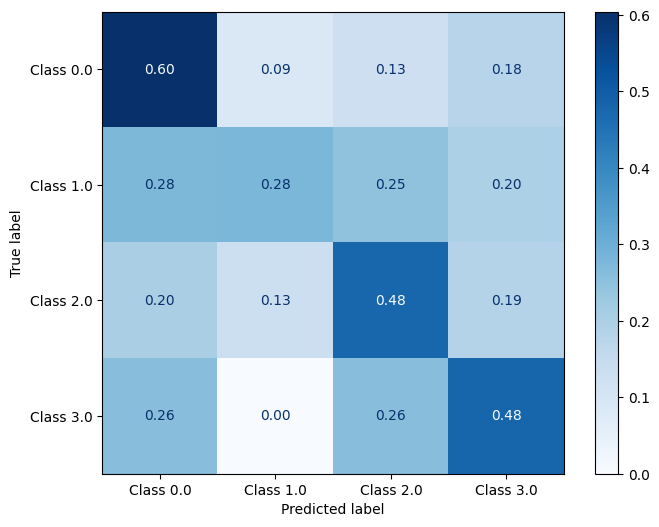

In [ ]:
# Confusion Matrix
# Prepare labels dynamically based on current target
unique_classes = sorted(list(set(y_test)))
labels = [f"Class {i}" for i in unique_classes]

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Use 'normalize=true' to see percentages per row
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=labels, 
    cmap=plt.cm.Blues,
    normalize='true', 
    ax=ax,
    values_format='.2f'
)